In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 50

AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# ============================================================
# DATASET PATHS
# ============================================================

PROJECT_PATH = (
    "/kaggle/input/datasets/"
    "mohansai7815/"
    "isic-256-dataset-zip/"
    "content/resized_dataset"
)

IMAGE_PATH = os.path.join(PROJECT_PATH, "images")
MASK_PATH = os.path.join(PROJECT_PATH, "masks")

print("Images:", len(os.listdir(IMAGE_PATH)))
print("Masks :", len(os.listdir(MASK_PATH)))

Images: 2594
Masks : 2594


In [4]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

images = sorted(os.listdir(IMAGE_PATH))

train_images, temp_images = train_test_split(
    images,
    test_size=0.20,
    random_state=SEED
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_images))
print("Val  :", len(val_images))
print("Test :", len(test_images))

Train: 2075
Val  : 259
Test : 260


In [5]:
# ============================================================
# CREATE DATAFRAMES
# ============================================================

def create_dataframe(image_list):
    data = []

    for image_name in image_list:
        image_path = os.path.join(IMAGE_PATH, image_name)

        mask_name = image_name.replace(
            ".jpg",
            "_segmentation.png"
        )

        mask_path = os.path.join(
            MASK_PATH,
            mask_name
        )

        data.append([image_path, mask_path])

    return pd.DataFrame(
        data,
        columns=["image", "mask"]
    )

train_df = create_dataframe(train_images)
val_df = create_dataframe(val_images)
test_df = create_dataframe(test_images)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2075, 2)
(259, 2)
(260, 2)


In [6]:
# ============================================================
# LOAD AND PREPROCESS DATA
# ============================================================

def read_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image


def read_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    mask = tf.image.resize(
        mask,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    mask = tf.cast(mask, tf.float32) / 255.0

    return mask

In [7]:
# ============================================================
# TF.DATA PIPELINE
# ============================================================

def load_data(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)

    return image, mask


def create_dataset(df, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["image"].values,
            df["mask"].values
        )
    )

    dataset = dataset.map(
        load_data,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [8]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = create_dataset(
    train_df,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_df,
    BATCH_SIZE
)

test_dataset = create_dataset(
    test_df,
    BATCH_SIZE
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


I0000 00:00:1785574601.797039      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785574601.800127      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
# ============================================================
# VERIFY DATASET SHAPES
# ============================================================

for images, masks in train_dataset.take(1):
    print("Image Batch Shape:", images.shape)
    print("Mask Batch Shape :", masks.shape)

Image Batch Shape: (16, 256, 256, 3)
Mask Batch Shape : (16, 256, 256, 1)


In [10]:
# ============================================================
# CELL 11 : CONVOLUTION BLOCK
# ============================================================

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

In [11]:
# ============================================================
# CELL 12 : CBAM ATTENTION BLOCK
# ============================================================

def cbam_block(inputs, reduction=8):

    channels = inputs.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    max_pool = layers.GlobalMaxPooling2D()(inputs)

    shared_dense_1 = layers.Dense(
        channels // reduction,
        activation="relu"
    )

    shared_dense_2 = layers.Dense(channels)

    avg_out = shared_dense_2(
        shared_dense_1(avg_pool)
    )

    max_out = shared_dense_2(
        shared_dense_1(max_pool)
    )

    channel_attention = layers.Add()(
        [avg_out, max_out]
    )

    channel_attention = layers.Activation(
        "sigmoid"
    )(channel_attention)

    channel_attention = layers.Reshape(
        (1, 1, channels)
    )(channel_attention)

    x = layers.Multiply()(
        [inputs, channel_attention]
    )

    avg_pool = layers.Lambda(
        lambda z: tf.reduce_mean(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    max_pool = layers.Lambda(
        lambda z: tf.reduce_max(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    concat = layers.Concatenate(
        axis=-1
    )([avg_pool, max_pool])

    spatial_attention = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    x = layers.Multiply()(
        [x, spatial_attention]
    )

    return x

In [12]:
# ============================================================
# CELL 13 : ENCODER BLOCK
# ============================================================

def encoder_block(inputs, filters):

    x = conv_block(
        inputs,
        filters
    )

    x = cbam_block(x)

    p = layers.MaxPooling2D(
        (2, 2)
    )(x)

    return x, p

In [13]:
# ============================================================
# CELL 14 : DECODER BLOCK
# ============================================================

def decoder_block(
    inputs,
    skip_features,
    filters
):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)

    x = layers.Concatenate()(
        [x, skip_features]
    )

    x = conv_block(
        x,
        filters
    )

    return x

In [14]:
# ============================================================
# CELL 15 : BUILD U-NET + CBAM
# ============================================================

def build_unet_cbam(
    input_shape=(256, 256, 3)
):

    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)

    s2, p2 = encoder_block(p1, 128)

    s3, p3 = encoder_block(p2, 256)

    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    b1 = cbam_block(b1)

    d1 = decoder_block(
        b1,
        s4,
        512
    )

    d2 = decoder_block(
        d1,
        s3,
        256
    )

    d3 = decoder_block(
        d2,
        s2,
        128
    )

    d4 = decoder_block(
        d3,
        s1,
        64
    )

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = models.Model(
        inputs,
        outputs,
        name="UNet_CBAM"
    )

    return model

In [20]:
# ============================================================
# CELL 16 : CREATE MODEL
# ============================================================

model = build_unet_cbam()

model.summary()

Model: "UNet_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 256, 256,  │     36,928 │ re_lu_18[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_19[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ re_lu_19[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8)         │        520 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │        576 │ dense_10[0][0],   │
│                     │                   │            │ dense_10[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 64)        │          0 │ dense_11[0][0],   │
│                     │                   │            │ dense_11[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64)        │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 64)  │          0 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 256, 256,  │          0 │ re_lu_19[0][0],   │
│ (Multiply)          │ 64)               │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 256, 256,  │          0 │ multiply_10[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 256, 256,  │          0 │ multiply_10[0][0] │
│                     │ 1)                │            │                 

 Total params: 31,407,208 (119.81 MB)

 Trainable params: 31,395,432 (119.76 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [16]:
# ============================================================
# CELL 17 : DICE COEFFICIENT
# ============================================================

def dice_coef(y_true, y_pred):

    smooth = 1e-7

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        + smooth
    )

In [17]:
# ============================================================
# CELL 18 : IOU METRIC
# ============================================================

def iou(y_true, y_pred):

    smooth = 1e-7

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    union = (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        - intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

In [18]:
# ============================================================
# CELL 19 : DICE LOSS
# ============================================================

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [19]:
# ============================================================
# CELL 20 : BCE + DICE LOSS
# ============================================================

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice

In [21]:
# ============================================================
# CELL 21 : COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LR
    ),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        iou
    ]
)

In [22]:
# ============================================================
# CELL 22 : CALLBACKS
# ============================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_unet_cbam.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [23]:
# ============================================================
# CELL 23 : TRAIN U-NET + CBAM
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


2026-08-01 09:17:07.447896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:17:07.678376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:17:16.071704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:17:16.362628: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01

129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - dice_coef: 0.5024 - iou: 0.3430 - loss: 0.9964

2026-08-01 09:20:04.063366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:20:04.291400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:20:05.566781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:20:05.873319: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:20:16.147308: E external/local_xla/xla/stream_

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.5030 - iou: 0.3436 - loss: 0.9947   

2026-08-01 09:21:21.906734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:21:22.124285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:21:22.974441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:21:23.268091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 09:21:29.076399: E external/local_xla/xla/stream_


Epoch 1: val_dice_coef improved from None to 0.26224, saving model to best_unet_cbam.keras

Epoch 1: finished saving model to best_unet_cbam.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - dice_coef: 0.5829 - iou: 0.4191 - loss: 0.7817 - val_dice_coef: 0.2622 - val_iou: 0.1513 - val_loss: 1.2675 - learning_rate: 1.0000e-04
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - dice_coef: 0.6920 - iou: 0.5318 - loss: 0.5330
Epoch 2: val_dice_coef improved from 0.26224 to 0.41513, saving model to best_unet_cbam.keras

Epoch 2: finished saving model to best_unet_cbam.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 115s 886ms/step - dice_coef: 0.7064 - iou: 0.5495 - loss: 0.5121 - val_dice_coef: 0.4151 - val_iou: 0.2633 - val_loss: 0.9652 - learning_rate: 1.0000e-04
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - dice_coef: 0.7449 - iou: 0.5961 - loss: 0.4355
Epoch 3: val_dice_coef improved from 0.41513 to 0.63567, saving model to best_unet_cbam.keras

Epoch 3: finished saving model to best

In [28]:
results = model.evaluate(test_dataset)

16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - dice_coef: 0.8790 - iou: 0.7860 - loss: 0.2769

2026-08-01 11:01:49.785574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 11:01:50.003519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 11:01:50.897513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 11:01:51.191415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 11:01:57.325796: E external/local_xla/xla/stream_

17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - dice_coef: 0.8712 - iou: 0.7744 - loss: 0.3197


In [29]:
test_loss, test_dice, test_iou = results

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")

Test Loss : 0.3197
Test Dice : 0.8712
Test IoU  : 0.7744


## U-Net + CBAM Results

 Test Loss : 0.3197
 Test Dice : 0.8712
 Test IoU  : 0.7744

Adding CBAM attention improved segmentation performance over the baseline U-Net.
The model achieved a Dice coefficient of 0.8712 and an IoU of 0.7744 on the ISIC 2018 test set, outperforming the baseline U-Net (Dice 0.8625, IoU 0.7596).
This indicates that channel and spatial attention help the network focus on informative lesion features.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


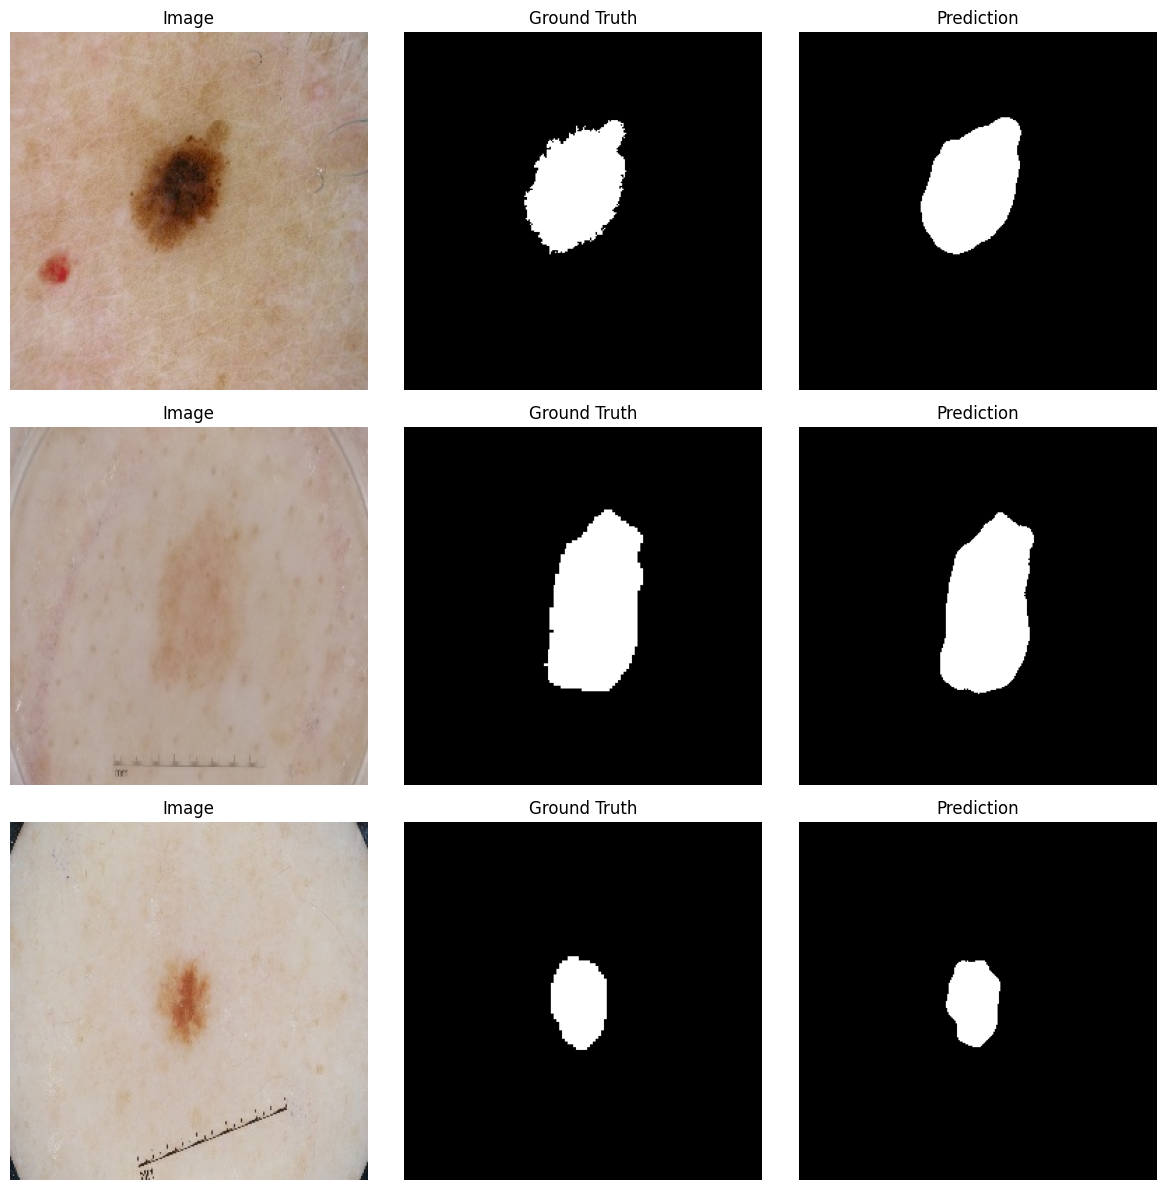

In [33]:
for images, masks in test_dataset.take(1):

    preds = model.predict(images)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    for i in range(3):

        axes[i,0].imshow(images[i])
        axes[i,0].set_title("Image")
        axes[i,0].axis("off")

        axes[i,1].imshow(
            tf.squeeze(masks[i]),
            cmap="gray"
        )
        axes[i,1].set_title("Ground Truth")
        axes[i,1].axis("off")

        axes[i,2].imshow(
            tf.squeeze(preds[i] > 0.5),
            cmap="gray"
        )
        axes[i,2].set_title("Prediction")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

    break